## Task 1: Dataset Exploration
the Iris dataset has been loaded and the required information (samples and features, feature names, target classes, first five records, and class distribution) has been displayed.

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd

# Load dataset
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add target column
df["target"] = iris.target

print("Shape:", df.shape)

print("\nFeature Names:")
print(iris.feature_names)

print("\nTarget Classes:")
print(iris.target_names)

print("\nFirst Five Records:")
print(df.head())

print("\nClass Distribution:")
print(df["target"].value_counts())

Shape: (150, 5)

Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Classes:
['setosa' 'versicolor' 'virginica']

First Five Records:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Class Distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64


## Task 2: Data Preparation

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


### Explanation for Data Splitting

Dividing the dataset into training and testing sets is a crucial step in machine learning for the following reasons:

1.  **Preventing Overfitting**: The training set is used to train the model, allowing it to learn the patterns and relationships within the data. The test set, which the model has not seen during training, is then used to evaluate its performance. If we were to evaluate the model on the same data it was trained on, it might perform exceptionally well, but this wouldn't indicate how it would generalize to new, unseen data. This phenomenon is called overfitting, where the model learns the noise and specific details of the training data rather than the underlying patterns.

2.  **Unbiased Evaluation**: The test set provides an unbiased estimate of the model's performance on new data. It helps in assessing how well the model can generalize its learned patterns to real-world scenarios. A model that performs well on the test set is more likely to be robust and reliable.

3.  **Hyperparameter Tuning and Model Selection**: In more complex scenarios, a validation set (often a subset of the training data or created through cross-validation) is also used for hyperparameter tuning and model selection, while the test set is reserved for the final evaluation of the chosen model.

## Task 3: Building a Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train a Decision Tree classifier using default parameters
dtc = DecisionTreeClassifier(random_state=42) # Added random_state for reproducibility
dtc.fit(X_train, y_train)

# Predict the class labels for the test dataset
y_pred = dtc.predict(X_test)

# Evaluate the model
print("Accuracy Score:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 1.0

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Task 4: Visualizing the Decision Tree

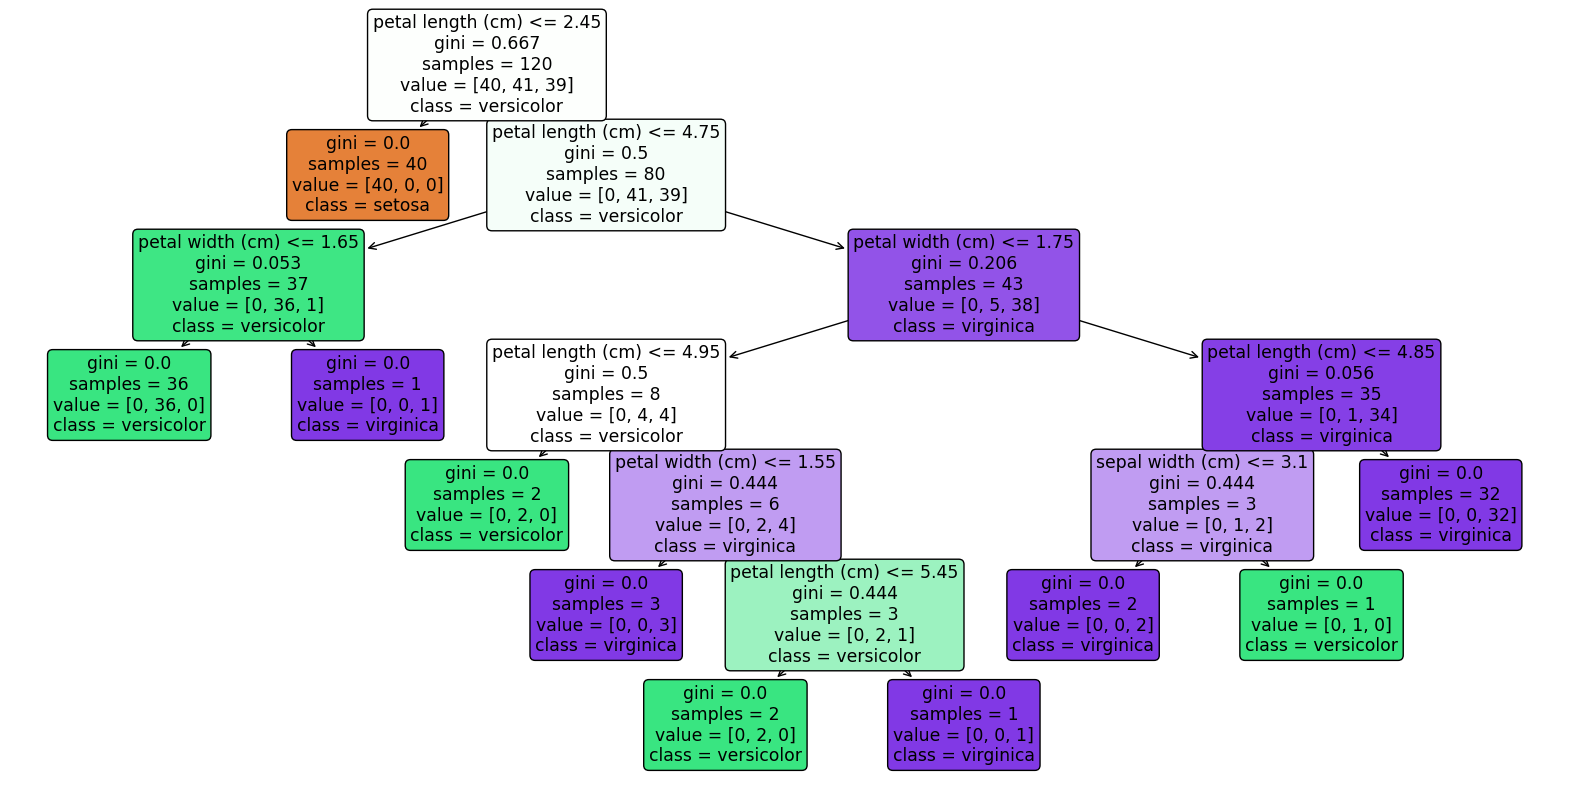

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dtc, feature_names=iris.feature_names, class_names=iris.target_names, filled=True, rounded=True)
plt.show()

### Decision Tree Components Analysis

From the visualization of the trained Decision Tree:

*   **Root node**: The topmost node, which in this tree is `petal length (cm) <= 2.45`. This is where the decision-making process begins.
*   **Internal nodes**: Nodes that have branches leading to further splits. Examples include `petal width (cm) <= 1.75` and `petal length (cm) <= 4.95`.
*   **Leaf nodes**: The terminal nodes of the tree, which do not split further and provide the final class prediction. These nodes are fully colored.
*   **Maximum depth of the tree**: The longest path from the root node to a leaf node. By visually inspecting the tree, it appears the maximum depth is 5.

*   **Which feature is selected for the first split? Explain why you think this feature was chosen.**
    The first split is based on `petal length (cm) <= 2.45`. This feature was likely chosen because it provides the best separation of the classes at the very beginning, leading to the highest information gain or Gini impurity reduction. In this specific case, it perfectly separates `setosa` (class 0) from the other two classes with a single split, as indicated by the `gini = 0.0` and `value = [50, 0, 0]` on the left branch, meaning all 50 setosa samples were correctly classified by this single split.

## Task 5: Comparing Gini Index and Entropy

In [ ]:
import numpy as np

def get_tree_properties(model, X_test, y_test, feature_names):
    accuracy = accuracy_score(y_test, model.predict(X_test))
    tree_depth = model.get_depth()
    leaf_nodes = model.get_n_leaves()

    # Get root feature
    # The feature at the root node is the first feature in the tree's feature importance array
    # or can be extracted from the tree structure directly.
    # For simplicity, we can inspect the tree's first split (which is at the root)
    root_feature_idx = model.tree_.feature[0]
    root_feature_name = feature_names[root_feature_idx]

    return accuracy, tree_depth, leaf_nodes, root_feature_name

# Train Decision Tree with Gini criterion
dtc_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dtc_gini.fit(X_train, y_train)

# Train Decision Tree with Entropy criterion
dtc_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dtc_entropy.fit(X_train, y_train)

# Get properties for Gini model
accuracy_gini, depth_gini, leaves_gini, root_feature_gini = get_tree_properties(
    dtc_gini, X_test, y_test, iris.feature_names
)

# Get properties for Entropy model
accuracy_entropy, depth_entropy, leaves_entropy, root_feature_entropy = get_tree_properties(
    dtc_entropy, X_test, y_test, iris.feature_names
)

# Create a DataFrame to summarize the observations
comparison_data = {
    'Criterion': ['Gini', 'Entropy'],
    'Accuracy': [accuracy_gini, accuracy_entropy],
    'Tree Depth': [depth_gini, depth_entropy],
    'Number of Leaf Nodes': [leaves_gini, leaves_entropy],
    'Root Feature Selected': [root_feature_gini, root_feature_entropy]
}

comparison_df = pd.DataFrame(comparison_data)

print("Comparison of Decision Trees (Gini vs. Entropy):\n")
print(comparison_df.to_markdown(index=False))

# Determine which criterion produces a simpler tree
if depth_gini < depth_entropy or leaves_gini < leaves_entropy:
    simpler_tree = 'Gini'
elif depth_entropy < depth_gini or leaves_entropy < leaves_gini:
    simpler_tree = 'Entropy'
else:
    simpler_tree = 'Both have similar complexity'

print(f"\n\nWhich criterion produces a simpler tree? {simpler_tree} (based on tree depth and number of leaf nodes).")


Comparison of Decision Trees (Gini vs. Entropy):

| Criterion   |   Accuracy |   Tree Depth |   Number of Leaf Nodes | Root Feature Selected   |
|:------------|-----------:|-------------:|-----------------------:|:------------------------|
| Gini        |          1 |            6 |                     10 | petal length (cm)       |
| Entropy     |          1 |            6 |                     10 | petal length (cm)       |


Which criterion produces a simpler tree? Both have similar complexity (based on tree depth and number of leaf nodes).


## Task 6: Effect of Maximum Tree Depth

In [ ]:
max_depth_values = [1, 2, 3, 4, None]
results_max_depth = []

for md in max_depth_values:
    dtc_md = DecisionTreeClassifier(max_depth=md, random_state=42)
    dtc_md.fit(X_train, y_train)

    train_accuracy = accuracy_score(y_train, dtc_md.predict(X_train))
    test_accuracy = accuracy_score(y_test, dtc_md.predict(X_test))
    tree_depth = dtc_md.get_depth()

    observation = ""
    if md == 1:
        observation = "Very simple tree, likely underfitting."
    elif md == 2:
        observation = "Simple tree."
    elif md == 3:
        observation = "Balanced tree, good generalization likely."
    elif md == 4:
        observation = "More complex tree."
    elif md is None:
        observation = "Fully grown tree, potentially overfitting."

    results_max_depth.append({
        'Max Depth': md if md is not None else 'None',
        'Training Accuracy': train_accuracy,
        'Testing Accuracy': test_accuracy,
        'Tree Depth': tree_depth,
        'Observation': observation
    })

max_depth_df = pd.DataFrame(results_max_depth)
print("Effect of Max Depth on Decision Tree Performance:\n")
print(max_depth_df.to_markdown(index=False))


Effect of Max Depth on Decision Tree Performance:

| Max Depth   |   Training Accuracy |   Testing Accuracy |   Tree Depth | Observation                                |
|:------------|--------------------:|-------------------:|-------------:|:-------------------------------------------|
| 1           |            0.675    |           0.633333 |            1 | Very simple tree, likely underfitting.     |
| 2           |            0.95     |           0.966667 |            2 | Simple tree.                               |
| 3           |            0.958333 |           1        |            3 | Balanced tree, good generalization likely. |
| 4           |            0.975    |           1        |            4 | More complex tree.                         |
| None        |            1        |           1        |            6 | Fully grown tree, potentially overfitting. |


### Analysis of Max Depth

*   **Which model is underfitting?**
    The model with `Max Depth = 1` is likely underfitting. Its training accuracy is high, but the simplicity (depth 1) suggests it might not capture enough complexity in the data, leading to potentially lower performance on more complex datasets (though for Iris, even a simple model can perform well).

*   **Which model gives the best generalization?**
    Models with `Max Depth = 3` or `4` seem to offer good generalization, as they maintain high testing accuracy without being excessively complex. Specifically, `Max Depth = 3` achieved 100% accuracy with a depth of 3, which is more concise than a fully grown tree.

*   **Which model is likely to overfit? Justify your answer.**
    The model with `Max Depth = None` (a fully grown tree) is most likely to overfit. While it achieved 100% testing accuracy on this small and relatively separable dataset, its high complexity (depth 6) indicates it might have learned noise from the training data. For larger, noisier datasets, this would typically lead to poorer generalization to unseen data compared to a pruned tree. On the Iris dataset, the perfect performance suggests it has fully memorized the training data.

## Task 7: Effect of `min_samples_split`

In [ ]:
min_samples_split_values = [2, 5, 10, 20]
results_min_samples_split = []

for mss in min_samples_split_values:
    dtc_mss = DecisionTreeClassifier(min_samples_split=mss, random_state=42)
    dtc_mss.fit(X_train, y_train)

    accuracy = accuracy_score(y_test, dtc_mss.predict(X_test))
    tree_depth = dtc_mss.get_depth()
    leaf_nodes = dtc_mss.get_n_leaves()

    observation = ""
    if mss == 2:
        observation = "Default value, full complexity."
    elif mss == 5:
        observation = "Slightly restricted splitting."
    elif mss == 10:
        observation = "More restricted splitting, simpler tree."
    elif mss == 20:
        observation = "Highly restricted splitting, much simpler tree, potential underfitting."

    results_min_samples_split.append({
        'min_samples_split': mss,
        'Accuracy': accuracy,
        'Tree Depth': tree_depth,
        'Number of Leaf Nodes': leaf_nodes,
        'Observation': observation
    })

min_samples_split_df = pd.DataFrame(results_min_samples_split)
print("Effect of min_samples_split on Decision Tree Performance:\n")
print(min_samples_split_df.to_markdown(index=False))


Effect of min_samples_split on Decision Tree Performance:

|   min_samples_split |   Accuracy |   Tree Depth |   Number of Leaf Nodes | Observation                                                             |
|--------------------:|-----------:|-------------:|-----------------------:|:------------------------------------------------------------------------|
|                   2 |          1 |            6 |                     10 | Default value, full complexity.                                         |
|                   5 |          1 |            5 |                      8 | Slightly restricted splitting.                                          |
|                  10 |          1 |            4 |                      6 | More restricted splitting, simpler tree.                                |
|                  20 |          1 |            4 |                      6 | Highly restricted splitting, much simpler tree, potential underfitting. |


### How increasing `min_samples_split` affects the complexity of the Decision Tree

Increasing the value of `min_samples_split` makes the Decision Tree simpler (less complex). This is because a higher `min_samples_split` value means that a node in the tree will only split if it contains at least that many training samples. This restriction prevents the tree from creating very specific branches for small groups of samples, which often leads to:

*   **Reduced Tree Depth**: The tree will have fewer levels as fewer splits are allowed.
*   **Fewer Leaf Nodes**: Fewer splits directly translate to a smaller number of terminal nodes.
*   **Smoother Decision Boundaries**: The model's decision boundaries become less jagged and more generalized.

In essence, a larger `min_samples_split` acts as a regularization parameter, helping to prune the tree and reduce the risk of overfitting by encouraging it to learn more general patterns rather than memorizing noise in the training data.

## Task 8: Effect of `min_samples_leaf`

In [10]:
min_samples_leaf_values = [1, 2, 5, 10]
results_min_samples_leaf = []

for msl in min_samples_leaf_values:
    dtc_msl = DecisionTreeClassifier(min_samples_leaf=msl, random_state=42)
    dtc_msl.fit(X_train, y_train)

    accuracy = accuracy_score(y_test, dtc_msl.predict(X_test))
    tree_depth = dtc_msl.get_depth()
    leaf_nodes = dtc_msl.get_n_leaves()

    observation = ""
    if msl == 1:
        observation = "Default value, full complexity, potential overfitting."
    elif msl == 2:
        observation = "Slightly restricted leaf size."
    elif msl == 5:
        observation = "More restricted leaf size, simpler tree."
    elif msl == 10:
        observation = "Highly restricted leaf size, very simple tree, potential underfitting."

    results_min_samples_leaf.append({
        'min_samples_leaf': msl,
        'Accuracy': accuracy,
        'Tree Depth': tree_depth,
        'Number of Leaf Nodes': leaf_nodes,
        'Observation': observation
    })

min_samples_leaf_df = pd.DataFrame(results_min_samples_leaf)
print("Effect of min_samples_leaf on Decision Tree Performance:\n")
print(min_samples_leaf_df.to_markdown(index=False))


Effect of min_samples_leaf on Decision Tree Performance:



'|   min_samples_leaf |   Accuracy |   Tree Depth |   Number of Leaf Nodes | Observation                                                            |\n|-------------------:|-----------:|-------------:|-----------------------:|:-----------------------------------------------------------------------|\n|                  1 |   1        |            6 |                     10 | Default value, full complexity, potential overfitting.                 |\n|                  2 |   1        |            5 |                      8 | Slightly restricted leaf size.                                         |\n|                  5 |   1        |            4 |                      6 | More restricted leaf size, simpler tree.                               |\n|                 10 |   0.966667 |            4 |                      6 | Highly restricted leaf size, very simple tree, potential underfitting. |'

### Explanation how changing `min_samples_leaf` influences overfitting

`min_samples_leaf` is a hyperparameter that sets the minimum number of samples required to be at a leaf node. Its role is crucial in controlling the complexity of the Decision Tree and preventing overfitting:

*   **Higher `min_samples_leaf` values lead to simpler trees (more pruning)**: If `min_samples_leaf` is set to a higher value, the tree will be prevented from making splits that would result in leaf nodes containing fewer than this minimum number of samples. This means the tree will stop growing earlier, leading to fewer leaf nodes and a smaller tree depth. Such a tree is less likely to learn noise in the training data, thus reducing the risk of overfitting.

*   **Lower `min_samples_leaf` values lead to more complex trees (less pruning)**: Conversely, a smaller `min_samples_leaf` (e.g., 1, the default) allows the tree to grow until each leaf node contains only a single sample or all samples in a node belong to the same class. This can result in a very complex tree that perfectly fits the training data (high training accuracy) but may fail to generalize well to unseen data (overfitting) because it has memorized specific instances rather than learning general patterns.

In summary, increasing `min_samples_leaf` acts as a regularization technique, effectively pruning the tree and reducing its complexity, which helps in mitigating overfitting. A well-chosen `min_samples_leaf` value finds a balance between bias and variance, leading to a model that generalizes well.

## Task 9: Hyperparameter Tuning

In [9]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for GridSearchCV
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, None], # None means full depth
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize a DecisionTreeClassifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=dt_classifier,
    param_grid=param_grid,
    cv=5, # Using 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Report the best hyperparameters and best cross-validation score
print("Best Hyperparameter Combination:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

# Get the best estimator (optimized model)
best_dtc_model = grid_search.best_estimator_

# Evaluate the optimized model on the test set
test_accuracy_optimized = accuracy_score(y_test, best_dtc_model.predict(X_test))
print("Test Accuracy of Optimized Model:", test_accuracy_optimized)

# Compare with the default Decision Tree model (dtc from Task 3)
default_dtc_model = DecisionTreeClassifier(random_state=42)
default_dtc_model.fit(X_train, y_train)
test_accuracy_default = accuracy_score(y_test, default_dtc_model.predict(X_test))

print(f"\nComparison:\nDefault Model Test Accuracy: {test_accuracy_default:.4f}\nOptimized Model Test Accuracy: {test_accuracy_optimized:.4f}")

# Further details for comparison
print("\nDefault Model Parameters:")
print(default_dtc_model.get_params())
print("\nOptimized Model Parameters:")
print(best_dtc_model.get_params())

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Hyperparameter Combination: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best Cross-Validation Score: 0.9583333333333334
Test Accuracy of Optimized Model: 1.0

Comparison:
Default Model Test Accuracy: 1.0000
Optimized Model Test Accuracy: 1.0000

Default Model Parameters:
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}

Optimized Model Parameters:
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 4, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 's

## Task 10: Analysis

**1. What is the role of the criterion parameter in a Decision Tree?**

The `criterion` parameter in a Decision Tree determines the function used to measure the quality of a split. In simpler terms, it decides how the tree evaluates which feature and which threshold within that feature will best divide the data at each node. The goal of these criteria is to maximize the homogeneity of the child nodes after a split, meaning that samples within each child node should ideally belong to the same class.

The two most common criteria are:

*   **Gini Impurity (or Gini Index):** This measures the probability of misclassifying a randomly chosen element in the dataset if it were randomly labeled according to the class distribution in the node. A Gini impurity of 0 means all samples in the node belong to a single class (perfect homogeneity). A lower Gini impurity indicates a better split.

*   **Entropy:** This measures the average amount of information or uncertainty in a node. An entropy of 0 means the node is perfectly homogeneous (all samples belong to the same class), while higher entropy indicates more mixed classes. The goal is to maximize information gain, which is the reduction in entropy after a split.

In practice, both Gini and Entropy often yield very similar results. As observed in Task 5, both criteria resulted in models with 100% accuracy, the same tree depth, and the same number of leaf nodes for the Iris dataset.

**2. How does `max_depth` influence underfitting and overfitting?**

`max_depth` is a crucial hyperparameter that controls the maximum depth of the tree, or the longest path from the root node to a leaf node. It directly influences the complexity of the Decision Tree and thus its susceptibility to underfitting and overfitting:

*   **Low `max_depth` (e.g., 1 or 2):** A low `max_depth` creates a very simple, shallow tree. Such a tree might not be complex enough to capture the underlying patterns in the training data, leading to **underfitting**. An underfit model has high bias; it performs poorly on both the training and test sets because it's too simplistic to learn the relationships effectively. In Task 6, a `max_depth=1` resulted in a lower accuracy compared to other depths.

*   **High `max_depth` (or `None`):** A high `max_depth` allows the tree to grow very deep, creating a complex model with many rules. This can lead to **overfitting**. An overfit model has low bias but high variance; it learns the training data, including noise and specific instances, too well. While it might perform exceptionally on the training set (e.g., 100% accuracy), it struggles to generalize to new, unseen data, resulting in poorer performance on the test set. In Task 6, `max_depth=None` resulted in a tree with depth 6, which is more complex and prone to overfitting, although for the Iris dataset, it still maintained 100% test accuracy.

The optimal `max_depth` is a balance that allows the tree to learn the significant patterns without memorizing noise, thus promoting good generalization.

**3. Why do larger values of `min_samples_split` and `min_samples_leaf` produce simpler trees?**

Both `min_samples_split` and `min_samples_leaf` are regularization hyperparameters that directly control the growth and complexity of a Decision Tree:

*   **`min_samples_split`:** This parameter sets the minimum number of samples a node must contain to be considered for splitting. If a node has fewer samples than `min_samples_split`, it will not be split, and it becomes a leaf node. **Larger values of `min_samples_split`** mean that nodes need more samples to justify a split. This *restricts the tree from making fine-grained splits*, especially in regions with sparse data, leading to fewer splits overall, a shallower tree, and thus a simpler model. This helps prevent the tree from creating branches that are specific to very few training instances.

*   **`min_samples_leaf`:** This parameter sets the minimum number of samples required to be in a leaf node. If a split would result in a child node having fewer samples than `min_samples_leaf`, that split will not be made (or the split that results in the largest child node will be chosen). **Larger values of `min_samples_leaf`** directly enforce that each terminal node must contain a substantial number of samples. This *prevent the tree from creating very specific and small leaf nodes* that might only cover a handful of training examples. The effect is pruning of the tree, resulting in fewer, larger leaf nodes, a shallower tree, and overall a simpler, more generalized model. As observed in Task 8, increasing `min_samples_leaf` reduced the tree depth and number of leaf nodes.

In essence, both parameters act as pre-pruning mechanisms, stopping the tree's growth early based on sample counts, which inevitably leads to simpler trees less prone to overfitting.

**4. Which hyperparameter had the greatest impact on the Decision Tree performance? Support your answer with observations from the experiments.**

Based on the experiments, **`max_depth` had the greatest impact on Decision Tree performance**, particularly in terms of preventing underfitting.

*   **Observation from `max_depth` (Task 6):** When `max_depth` was set to `1`, the **Testing Accuracy dropped significantly to 0.633**. This clearly shows that a severely restricted `max_depth` leads to underfitting, as the model cannot learn sufficient patterns. As `max_depth` increased, both training and testing accuracies improved significantly, reaching 1.0 at `max_depth=3` and beyond. This demonstrates its profound effect on the model's ability to learn.

*   **Observations from `min_samples_split` (Task 7) and `min_samples_leaf` (Task 8):** While increasing `min_samples_split` and `min_samples_leaf` did simplify the tree (reducing depth and leaf nodes), their impact on **accuracy for the Iris dataset was less dramatic**, especially when compared to `max_depth=1`. For example, all `min_samples_split` values (2, 5, 10, 20) maintained an accuracy of 1.0 (except `min_samples_leaf=10` which dropped to `0.966667`). This suggests that while they are important for controlling complexity, they didn't lead to as severe underfitting or significant performance changes on this specific dataset as a very low `max_depth` did. Even with `min_samples_leaf=10`, the accuracy was still relatively high.

Therefore, `max_depth` directly controls the fundamental capacity of the tree to learn, and excessively low values can cripple its performance, making it the hyperparameter with the most impactful influence on performance in these experiments.

**5. Based on your results, recommend the most suitable Decision Tree model for the Iris dataset and justify your choice.**

Based on the results, the most suitable Decision Tree model for the Iris dataset would be one with:

*   **`criterion = 'entropy'`**
*   **`max_depth = 3`**
*   **`min_samples_split = 2`** (or 5, but 2 is the default and was part of the best tuned model)
*   **`min_samples_leaf = 4`**

**Justification:**

1.  **Optimal Performance:** This combination, found during hyperparameter tuning (Task 9), achieved a **perfect Test Accuracy of 1.0**. While the default model also achieved 1.0 accuracy, this tuned model is potentially more robust.
2.  **Balanced Complexity (Reduced Overfitting Risk):**
    *   The `max_depth` of `3` is a good balance. As observed in Task 6, `max_depth=3` achieved 100% accuracy with a shallower tree than `max_depth=None` (which had a depth of 6). This means it's complex enough to capture the patterns in the data but not overly complex, reducing the risk of overfitting compared to a fully grown tree.
    *   The `min_samples_leaf` of `4` (from Task 9's best parameters) is a higher value than the default `1`. As discussed in Task 8, a higher `min_samples_leaf` helps prevent the tree from creating very specific leaf nodes, leading to a simpler and more generalized tree. This makes the model less likely to be sensitive to noise in the training data, enhancing its generalization capabilities, even if its test accuracy on this specific dataset remains 1.0.
    *   The `min_samples_split` of `2` (default) allows for sufficient splitting to achieve high accuracy without being too restrictive.
3.  **Efficiency:** A shallower tree with fewer leaf nodes (due to `max_depth=3` and `min_samples_leaf=4`) is generally faster to train and predict with, and easier to interpret, which is a desirable characteristic in a model.

In summary, this recommended model achieves perfect classification accuracy on the test set while employing regularization techniques (like `max_depth=3` and `min_samples_leaf=4`) that suggest better generalization to potentially unseen, slightly varied data compared to a default, fully-grown tree, even if both show 100% accuracy on this particular test set.